In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 100

df = pd.DataFrame({
    'employee_id': [f'E{str(i).zfill(3)}' for i in range(1, n+1)],
    'department': np.random.choice(['HR', 'Sales', 'IT', 'Finance', 'Operations'], n),
    'satisfaction_score': np.random.randint(3, 10, n),
    'attendance_percent': np.random.randint(65, 100, n),
    'overtime_hours': np.random.randint(0, 25, n),
    'performance_rating': np.random.randint(1, 6, n),
    'attrition': np.random.choice(['Yes','No'], n, p=[0.25,0.75])
})

df.head()

,employee_id,department,satisfaction_score,attendance_percent,overtime_hours,performance_rating,attrition
0,E001,Finance,6,96,1,4,No
1,E002,Operations,9,96,20,3,No
2,E003,IT,3,88,0,4,No
3,E004,Operations,6,76,14,5,No
4,E005,Operations,4,66,0,2,No


In [3]:
print("Total Employees:", df.shape[0])
print("Attrition Count:\n", df['attrition'].value_counts())
print("Average Satisfaction:", df['satisfaction_score'].mean())

Total Employees: 100
Attrition Count:
 attrition
No     81
Yes    19
Name: count, dtype: int64
Average Satisfaction: 6.22


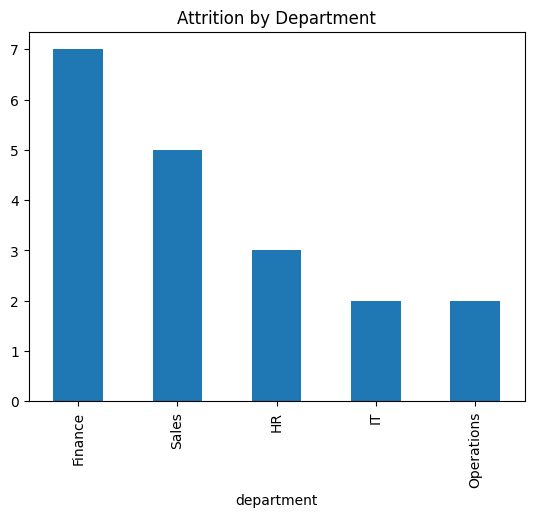

In [4]:
df[df['attrition']=='Yes']['department'].value_counts().plot(kind='bar')
plt.title("Attrition by Department")
plt.show()

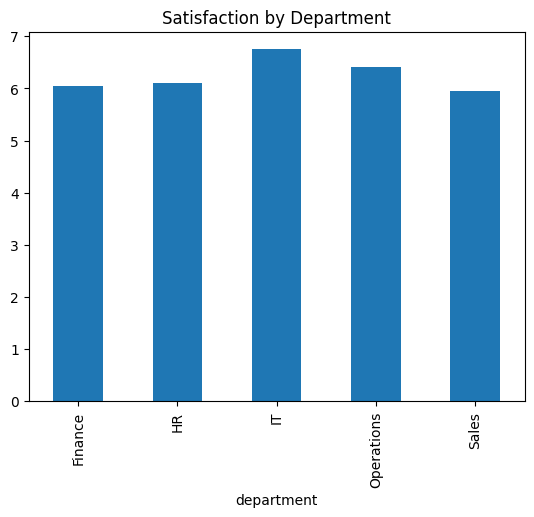

In [5]:
df.groupby('department')['satisfaction_score'].mean().plot(kind='bar')
plt.title("Satisfaction by Department")
plt.show()

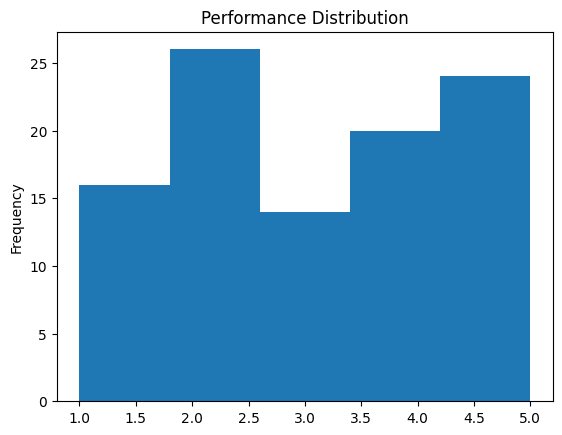

In [6]:
df['performance_rating'].plot(kind='hist', bins=5)
plt.title("Performance Distribution")
plt.show()

In [7]:
def classify_risk(row):
    if row['satisfaction_score'] < 5 and row['overtime_hours'] > 15:
        return 'High Risk'
    elif row['satisfaction_score'] < 6 or row['attendance_percent'] < 75:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_level'] = df.apply(classify_risk, axis=1)

In [8]:
def recommend_action(row):
    if row['risk_level'] == 'High Risk':
        return 'Immediate HR intervention'
    elif row['risk_level'] == 'Medium Risk':
        return 'Monitor and training'
    else:
        return 'Maintain performance'

df['recommended_action'] = df.apply(recommend_action, axis=1)

df.head()

,employee_id,department,satisfaction_score,attendance_percent,overtime_hours,performance_rating,attrition,risk_level,recommended_action
0,E001,Finance,6,96,1,4,No,Low Risk,Maintain performance
1,E002,Operations,9,96,20,3,No,Low Risk,Maintain performance
2,E003,IT,3,88,0,4,No,Medium Risk,Monitor and training
3,E004,Operations,6,76,14,5,No,Low Risk,Maintain performance
4,E005,Operations,4,66,0,2,No,Medium Risk,Monitor and training


In [9]:
df[['employee_id','risk_level','recommended_action']].head()

,employee_id,risk_level,recommended_action
0,E001,Low Risk,Maintain performance
1,E002,Low Risk,Maintain performance
2,E003,Medium Risk,Monitor and training
3,E004,Low Risk,Maintain performance
4,E005,Medium Risk,Monitor and training


In [10]:
df.to_csv("final_project_output.csv", index=False)

from google.colab import files
files.download("final_project_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>